# 🛠️ Preparación de los Datos





In [90]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   Churn             7043 non-null   object 
 2   gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   int64  
 4   Partner           7043 non-null   object 
 5   Dependents        7043 non-null   object 
 6   tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   object 
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-null   object 
 16  Contract          7043 non-null   object 


In [91]:
df.isnull().sum()

,0
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


In [92]:
df = df.drop("customerID", axis=1)

In [93]:
df["Churn"] = df["Churn"].map({"Yes":1, "No":0})

In [94]:
df["Churn"].value_counts()

,count
Churn,
0,5174
1,1869


In [95]:
df["Churn"].value_counts(normalize=True)

,proportion
Churn,
0,0.73463
1,0.26537


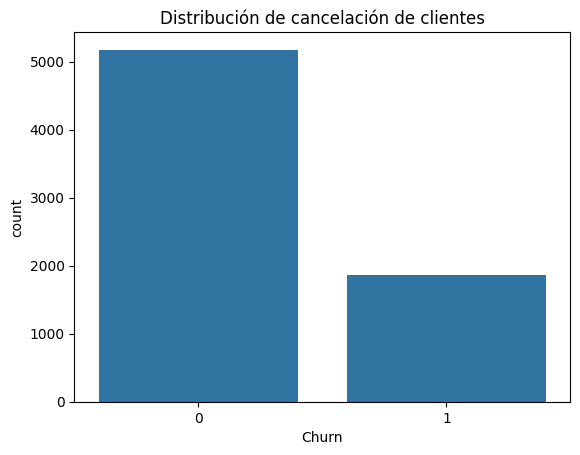

In [96]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Churn", data=df)
plt.title("Distribución de cancelación de clientes")
plt.show()

Se analizó la proporción de clientes que cancelaron el servicio en comparación con aquellos que permanecen activos. Los resultados muestran que aproximadamente el 27% de los clientes cancelaron, mientras que el 73% continúan utilizando el servicio.

Aunque existe cierta diferencia entre las clases, el desbalance no es extremo, por lo que los modelos de machine learning pueden entrenarse sin necesidad inmediata de aplicar técnicas de balanceo.


# 🎯 Correlación y Selección de Variables






In [100]:
corr_churn = df.select_dtypes(include=["number"]).corr()["Churn"].sort_values(ascending=False)

corr_churn

,Churn
Churn,1.000000
MonthlyCharges,0.193356
SeniorCitizen,0.150889
TotalCharges,-0.198324
tenure,-0.352229


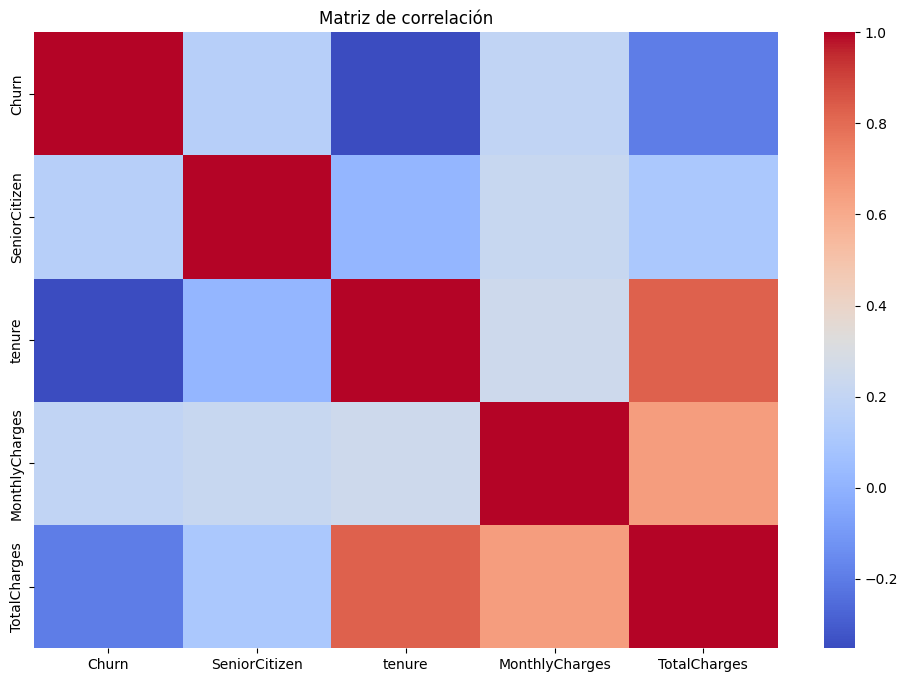

In [98]:
corr = df.select_dtypes(include=["number"]).corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Matriz de correlación")
plt.show()

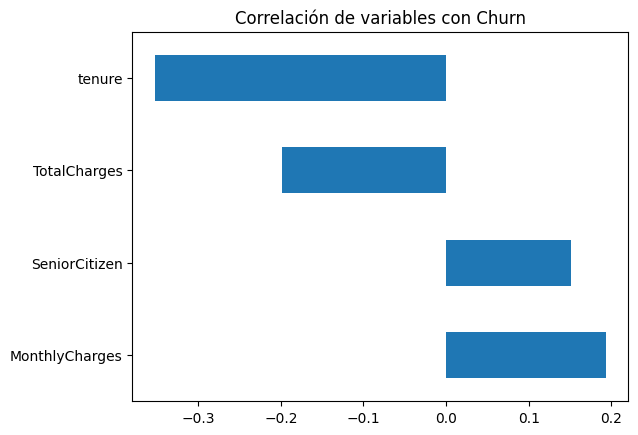

In [101]:
corr_churn.drop("Churn").plot(kind="barh")
plt.title("Correlación de variables con Churn")
plt.show()

El análisis de correlación permitió identificar algunas variables con relación a la cancelación del servicio. La variable tenure presenta una correlación negativa moderada con churn, lo que indica que los clientes con mayor antigüedad tienden a permanecer en el servicio. Asimismo, TotalCharges también muestra una relación negativa, lo que sugiere que los clientes que han acumulado mayor gasto total suelen mantenerse activos.

Por otro lado, MonthlyCharges presenta una correlación positiva, lo que indica que cargos mensuales más altos podrían estar asociados con una mayor probabilidad de cancelación. Finalmente, la variable SeniorCitizen muestra una correlación positiva leve con churn.

Estos resultados sugieren que el tiempo de permanencia y el costo del servicio son factores relevantes para comprender el comportamiento de cancelación de clientes.

# 🤖 Modelado Predictivo





In [105]:
df = pd.get_dummies(df, drop_first=True)

In [102]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [109]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [110]:
print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

Datos de entrenamiento: (5634, 19)
Datos de prueba: (1409, 19)


In [112]:
df.dtypes

,0
Churn,int64
SeniorCitizen,int64
tenure,int64
MonthlyCharges,float64
TotalCharges,float64
gender_Male,bool
Partner_Yes,bool
Dependents_Yes,bool
PhoneService_Yes,bool
MultipleLines_No phone service,bool


In [113]:
df = df.astype(int)

In [114]:
df = df.astype({col: int for col in df.select_dtypes(include="bool").columns})

In [115]:
df = df.astype({col: int for col in df.select_dtypes(include="bool").columns})

In [116]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [117]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

Datos de entrenamiento: (5634, 30)
Datos de prueba: (1409, 30)


**Normalización**

In [118]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Modelo 1: Regresión Logística**

In [119]:
from sklearn.linear_model import LogisticRegression

modelo_lr = LogisticRegression(max_iter=1000)
modelo_lr.fit(X_train_scaled, y_train)

pred_lr = modelo_lr.predict(X_test_scaled)

**Evaluación**

In [120]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, pred_lr))
print(classification_report(y_test, pred_lr))
print(confusion_matrix(y_test, pred_lr))

Accuracy: 0.8076650106458482
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1036
           1       0.67      0.54      0.60       373

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.74      1409
weighted avg       0.80      0.81      0.80      1409

[[937  99]
 [172 201]]


Modelo 2: Random Forest

In [121]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(random_state=42)
modelo_rf.fit(X_train, y_train)

pred_rf = modelo_rf.predict(X_test)

Evaluación

In [122]:
print("Accuracy:", accuracy_score(y_test, pred_rf))
print(classification_report(y_test, pred_rf))
print(confusion_matrix(y_test, pred_rf))

Accuracy: 0.7877927608232789
              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1036
           1       0.64      0.45      0.53       373

    accuracy                           0.79      1409
   macro avg       0.73      0.68      0.69      1409
weighted avg       0.77      0.79      0.77      1409

[[944  92]
 [207 166]]


Importancia de variables

In [123]:
import pandas as pd
import matplotlib.pyplot as plt

importancia = pd.Series(
    modelo_rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importancia.head(10))

TotalCharges                      0.193205
tenure                            0.178329
MonthlyCharges                    0.128183
PaymentMethod_Electronic check    0.043278
InternetService_Fiber optic       0.038868
Contract_Two year                 0.032927
gender_Male                       0.031978
PaperlessBilling_Yes              0.029450
OnlineSecurity_Yes                0.027004
Partner_Yes                       0.024941
dtype: float64


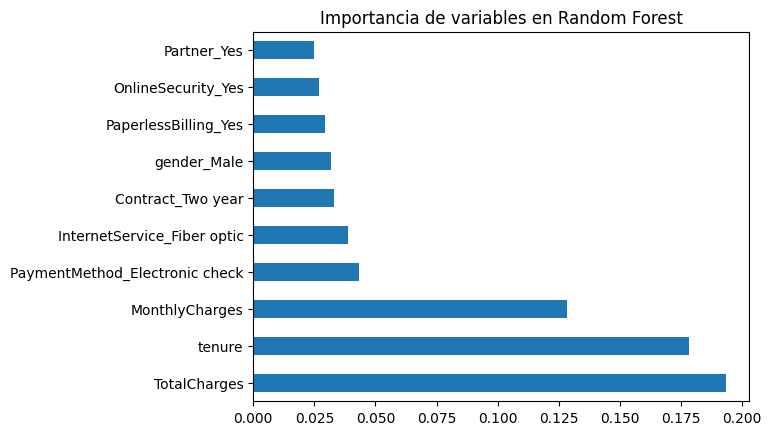

In [124]:
importancia.head(10).plot(kind="barh")
plt.title("Importancia de variables en Random Forest")
plt.show()

# 📋 Interpretación y Conclusiones

El análisis permitió identificar patrones relevantes en el comportamiento de cancelación de clientes. Los modelos predictivos mostraron que variables relacionadas con el tiempo de permanencia, los cargos del servicio y el tipo de servicio contratado influyen significativamente en la probabilidad de churn. Entre los modelos evaluados, la regresión logística obtuvo el mejor desempeño, alcanzando una precisión cercana al 81%. Estos resultados sugieren que la empresa podría utilizar este tipo de modelos para anticipar posibles cancelaciones y desarrollar estrategias de retención dirigidas a los clientes con mayor riesgo de abandonar el servicio.